In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.resources import INLINE
from bokeh.io import output_notebook
output_notebook(INLINE)
from os.path import join

Loading BokehJS ...

In [5]:
sample_list = list(pd.read_csv('/path/to/data/p6/EGA_haplotypecaller/sample_list.txt', header=None).iloc[:,0])
sample_list.remove('PDNEW36a')
sample = 'PD4060b2'
sample = sample_list[30]
basedir = '/path/to/data/p6/EGA_haplotypecaller/'
chr = 9 
f = join(basedir, f"chr{chr}", f"{sample}_roh.txt.gz")


In [9]:
# use comment to skip RG or ST lines, this is obviously just a temoporary fix
df_ST = pd.read_csv(f, sep='\t', skiprows=5, comment='R', header=None)
df_R = pd.read_csv(f, sep='\t', skiprows=5, comment='S', header=None)
df_ST.columns = ['class', 'sample', 'chr', 'pos', 'roh', 'prob']
df_R.columns = ['class', 'sample', 'chr', 'start', 'end', 'length', 'num_markers', 'quality']
df_sub = df_ST.loc[(df.pos>2000000) & (df.pos<8000000)]

In [11]:
print(df_R)
print(np.sum(df_R.length))

   class   sample   chr      start        end   length  num_markers  quality
0     RG  PD4779a  chr9     116638    3182735  3066098         1348     45.6
1     RG  PD4779a  chr9    3395436    5765190  2369755          896     66.1
2     RG  PD4779a  chr9    6532937   15015971  8483035         1850     54.3
3     RG  PD4779a  chr9   15048214   19573284  4525071         1629     38.4
4     RG  PD4779a  chr9   20789005   25995509  5206505          804     45.4
5     RG  PD4779a  chr9   26490354   33328535  6838182         2788     67.9
6     RG  PD4779a  chr9   33887064   34718258   831195          682     13.5
7     RG  PD4779a  chr9   35557734   36519926   962193         1023     33.6
8     RG  PD4779a  chr9   44880249   45352230   471982          101     10.1
9     RG  PD4779a  chr9   72659078   73205658   546581          222     18.0
10    RG  PD4779a  chr9   95263176   95817926   554751          459     37.8
11    RG  PD4779a  chr9   96162380   97059103   896724          431     39.1

In [7]:
p = figure(plot_height = 300, plot_width = 600, title=sample, x_axis_label=f'Chr{chr} genomic_coordinate', y_axis_label='ROH Model')
p.line(df_sub.pos, df_sub.roh, line_width=2)
show(p)

In [45]:
p = figure(plot_height = 300, plot_width = 1000, title=sample, x_axis_label='Chr9 genomic_coordinate', y_axis_label='ROH Model')
p.line(df.pos, df.roh, line_width=2)
show(p)

In [15]:
# what's the total amount of LOH that is encompassed in this sample?
def calculate_roh_df(df):
    current_state=0
    counter=0
    roh_starts = []
    roh_ends = []
    for roh, pos in zip(df.roh, df.pos):
        if current_state==0:
            if roh ==1:
                counter +=1 
                roh_starts.append(pos)
                current_state=1
        else: 
            if roh==0:
                current_state=0
                roh_ends.append(pos)
    roh_calcs = pd.DataFrame({'start': roh_starts[0:len(roh_ends)], 
                          'end' : roh_ends[0:len(roh_ends)]})
    roh_calcs['len'] = [a-b for a,b in zip(roh_calcs['end'], roh_calcs['start'])]    
    return(roh_calcs)

In [16]:
basedir = '/path/to/data/p6/EGA_haplotypecaller/'
chr_list = list(range(1,23))

# do this for each chromosome 
for chr in chr_list:
    print(chr)
    roh_calcs_dict = {}
    total_roh_length_dict = {}
    roh_number_dict = {}
    for sample in sample_list:
        f = join(basedir, f"chr{chr}", f"{sample}_roh.txt")
        df = pd.read_csv(f, sep='\t', skiprows=5, comment='R', header=None)
        df.columns = ['class', 'sample', 'chr', 'pos', 'roh', 'prob']
        roh_calcs = calculate_roh_df(df)
        total_roh_length = np.sum(roh_calcs['len'])
        roh_number = roh_calcs.shape[0]    
        total_roh_length_dict[sample] = total_roh_length
        roh_number_dict[sample] = roh_number
    roh_stats_df = pd.DataFrame({'sample': sample_list,
                             'roh_number': [roh_number_dict[s] for s in sample_list],
                             'roh_total_length': [total_roh_length_dict[s] for s in sample_list]})
    roh_stats_df.index = roh_stats_df['sample']
    outf = join(basedir, 'roh_stats_df', f"chr{chr}_roh_stats.txt")
    roh_stats_df.to_csv(outf, sep='\t')

1


In [38]:
roh_stats_df = pd.DataFrame({'sample': sample_list,
                             'roh_number': [roh_number_dict[s] for s in sample_list],
                             'roh_total_length': [total_roh_length_dict[s] for s in sample_list]})
roh_stats_df.index = roh_stats_df['sample']
roh_stats_df


,sample,roh_number,roh_total_length
sample,,,
1711STDY5270146,1711STDY5270146,91,69646342.0
1711STDY5270147,1711STDY5270147,87,64222243.0
1711STDY5270148,1711STDY5270148,84,59430599.0
1712STDY5304131,1712STDY5304131,63,79288128.0
1712STDY5304137,1712STDY5304137,69,77823518.0
...,...,...,...
PDNEW34a,PDNEW34a,73,63555977.0
PDNEW34b,PDNEW34b,62,55556313.0
PDNEW35a,PDNEW35a,79,60199992.0


In [18]:
# load the EGA metadata
ega_metadata = pd.read_csv('/home/user/projects/project/p6_investigation/EGA_metadata.tsv', sep='\t')
ega_metadata.index = ega_metadata['sample']

In [36]:
roh_number_dict[sample_list]

TypeError: unhashable type: 'list'

In [39]:

ega_metadata_join = ega_metadata.join(roh_stats_df, lsuffix='new')
ega_metadata_join


,samplenew,EGAF,bamfile,patient,timepoint,tumor_normal,library,platform,platform_unit,study,tumor.normal.pair,exclude.pair.filter,sample,roh_number,roh_total_length
sample,,,,,,,,,,,,,,,
1711STDY5270146,1711STDY5270146,EGAF00000120999,data-bucket/data/EGAF00000120999/7559_1#5.bam,1711STDY5270146,1,T,1,ILLUMINA,unit1,PV,False,False,1711STDY5270146,91.0,69646342.0
1711STDY5270147,1711STDY5270147,EGAF00000121000,data-bucket/data/EGAF00000121000/7559_1#6.bam,1711STDY5270147,1,T,1,ILLUMINA,unit1,PV,False,False,1711STDY5270147,87.0,64222243.0
1711STDY5270148,1711STDY5270148,EGAF00000121001,data-bucket/data/EGAF00000121001/7559_1#7.bam,1711STDY5270148,1,T,1,ILLUMINA,unit1,PV,False,False,1711STDY5270148,84.0,59430599.0
1712STDY5304131,1712STDY5304131,EGAF00000119256,data-bucket/data/EGAF00000119256/7820_7#8.bam,1712STDY5304131,1,T,1,ILLUMINA,unit1,PMF,False,False,1712STDY5304131,63.0,79288128.0
1712STDY5304137,1712STDY5304137,EGAF00000122102,data-bucket/data/EGAF00000122102/7846_4#6.bam,1712STDY5304137,1,T,1,ILLUMINA,unit1,PMF,False,False,1712STDY5304137,69.0,77823518.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PDNEW34b,PDNEW34b,EGAF00000122108,data-bucket/data/EGAF00000122108/7846_5#4.bam,PDNEW34,1,T,1,ILLUMINA,unit1,PMF,True,False,PDNEW34b,62.0,55556313.0
PDNEW35a,PDNEW35a,EGAF00000147105,data-bucket/data/EGAF00000147105/8251_7#6.bam,PDNEW35,1,N,2,ILLUMINA,unit1,PMF,True,False,PDNEW35a,79.0,60199992.0
PDNEW35b,PDNEW35b,EGAF00000122111,data-bucket/data/EGAF00000122111/7846_6#7.bam,PDNEW35,1,T,1,ILLUMINA,unit1,PMF,True,False,PDNEW35b,50.0,44948464.0


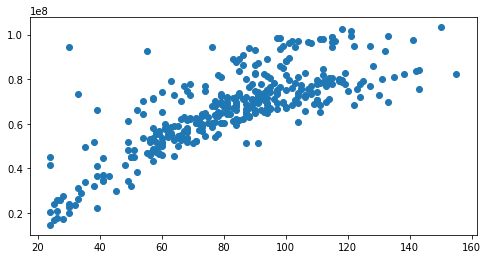

In [35]:
fig, ax = plt.subplots(figsize=(8,4))
ax.scatter(ega_metadata_join['roh_number'], ega_metadata_join['roh_total_length'])
plt.show()

In [41]:
ega_metadata_join.to_csv('~/data/p6/EGA_haplotypecaller/metadata_join_roh.tsv', sep='\t')